In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=(0.5, 0.5, 0.5),
    std=(0.5, 0.5, 0.5)
)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
    mean=(0.5, 0.5, 0.5),
    std=(0.5, 0.5, 0.5)
)
])
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 50000
Test size: 10000


In [2]:
classes = (
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)


In [30]:
img, label = train_dataset[1]
print([classes[label] for label in labels[:10]])

['horse', 'dog', 'ship', 'airplane', 'ship', 'bird', 'horse', 'airplane', 'cat', 'dog']


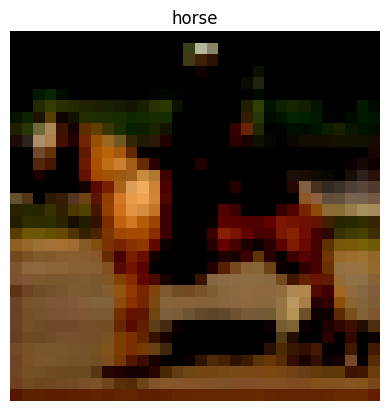

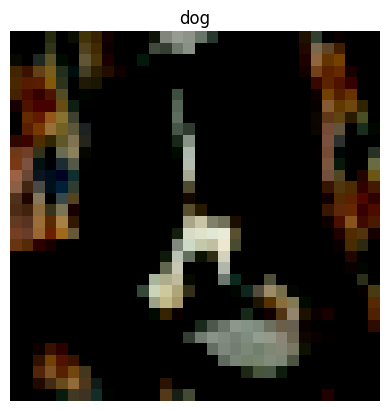

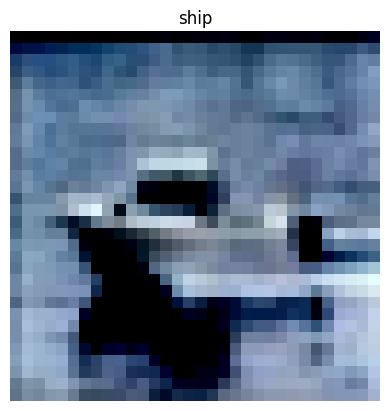

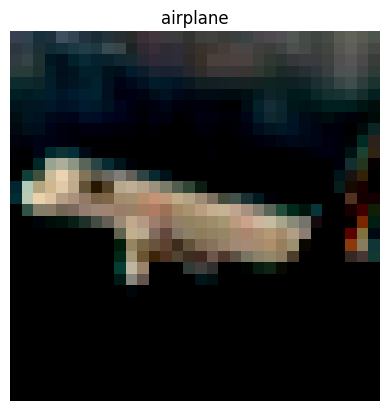

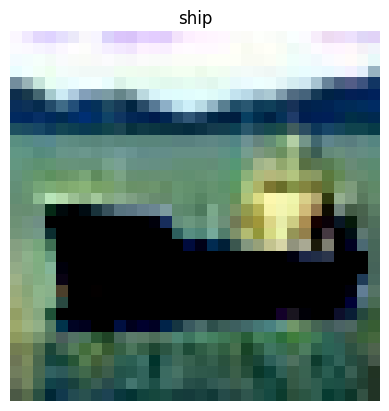

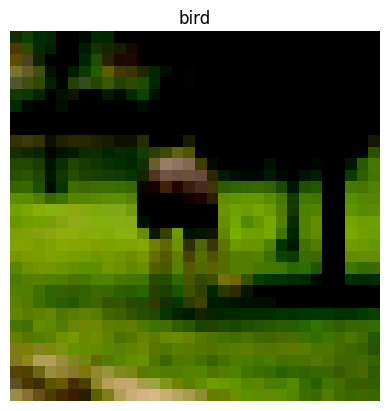

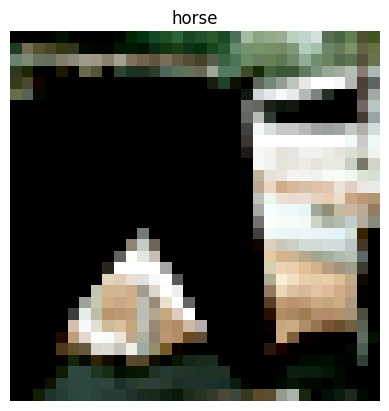

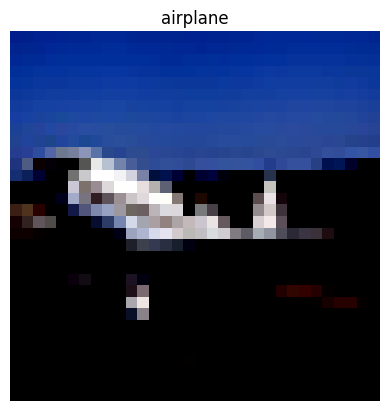

In [32]:
import matplotlib.pyplot as plt

# Show first 8 images with labels
for i in range(8):
    img = images[i].cpu().numpy().transpose(1, 2, 0)  # move to CPU, CHW -> HWC
    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis('off')
    plt.show()

In [4]:
print(img.shape, label)


torch.Size([3, 32, 32]) 9


In [5]:
img.min(), img.max()

(tensor(-1.), tensor(0.9922))

In [6]:
img = img * 0.5 +0.5

In [7]:
img.min(), img.max()

(tensor(0.), tensor(0.9961))

In [8]:
img = img.permute(1, 2, 0)

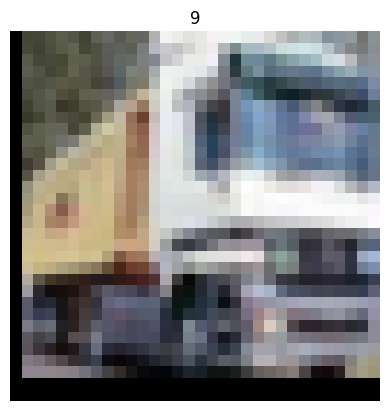

In [9]:
plt.imshow(img)
plt.title(str(label))
plt.axis("off")
plt.show()

In [10]:

class SmallCNN(nn.Module):
    def __init__(self,classes=10):
        super(SmallCNN,self).__init__()
        self.conv1 = nn.Conv2d(3,32,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256,classes)
    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0),-1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [11]:
class SmallCNN_ResNet(nn.Module):
    def __init__(self, classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.resblock = ResNetBlock(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = self.resblock(x)

        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
model = SmallCNN()
model.to(device)

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [14]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


In [15]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [16]:
num_epochs = 10
best_acc = 0.0

early_stopper = EarlyStopping(patience=5)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
for epo in range(num_epochs):
    model.train()
    run_loss = 0.0
    val_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = run_loss / len(train_loader)
    if early_stopper(loss):
        break
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()

    val_loss /= len(test_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if early_stopper(val_loss):
        print("early stopping break")
        break
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_cnn_cifar10.pth")
        print("Best model saved")



    print(f"epoch = {epo+1} ==> loss = {train_loss} ==> accuracy = {train_acc} ==> val accuracy = {val_acc}")

Best model saved
epoch = 1 ==> loss = 1.5823541687577583 ==> accuracy = 41.628 ==> val accuracy = 57.78
Best model saved
epoch = 2 ==> loss = 1.2758389414881197 ==> accuracy = 54.126 ==> val accuracy = 65.0
Best model saved
epoch = 3 ==> loss = 1.1487093513731457 ==> accuracy = 59.28 ==> val accuracy = 66.72
Best model saved
epoch = 4 ==> loss = 1.0647194452602844 ==> accuracy = 62.258 ==> val accuracy = 71.42
epoch = 5 ==> loss = 1.0024823926751265 ==> accuracy = 64.59 ==> val accuracy = 70.83
Best model saved
epoch = 6 ==> loss = 0.9502666032375278 ==> accuracy = 66.872 ==> val accuracy = 72.52
epoch = 7 ==> loss = 0.912313562829781 ==> accuracy = 68.248 ==> val accuracy = 71.83
Best model saved
epoch = 8 ==> loss = 0.873193757346524 ==> accuracy = 69.732 ==> val accuracy = 75.04
Best model saved
epoch = 9 ==> loss = 0.8516694497116997 ==> accuracy = 70.592 ==> val accuracy = 75.14
Best model saved
epoch = 10 ==> loss = 0.8212567004553802 ==> accuracy = 71.816 ==> val accuracy = 77.2

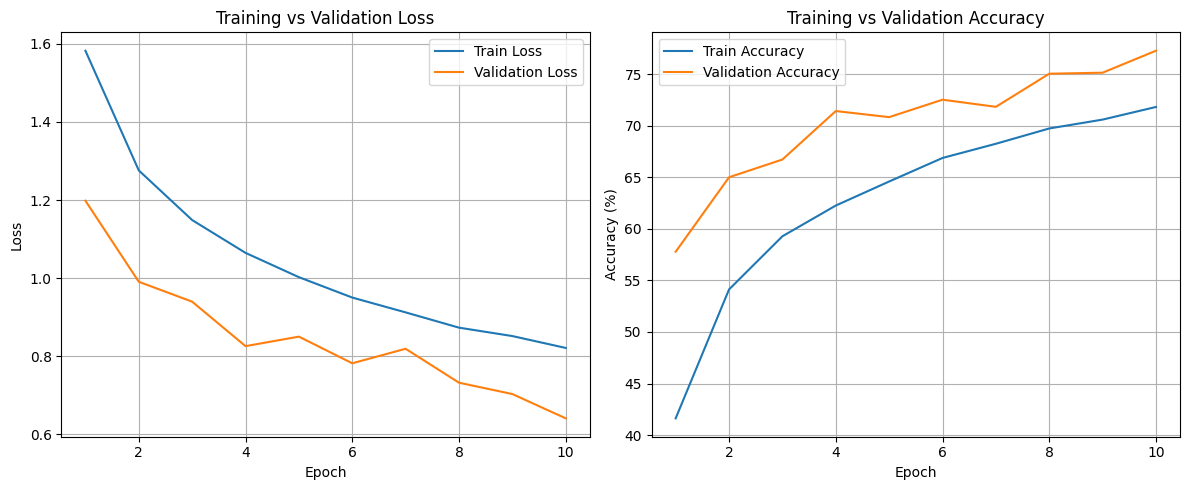

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [18]:
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(images.size(0)):
            if preds[i] != labels[i]:
                misclassified.append((
                    images[i].cpu(),
                    labels[i].cpu(),
                    preds[i].cpu()
                ))

        if len(misclassified) >= 10:
            break


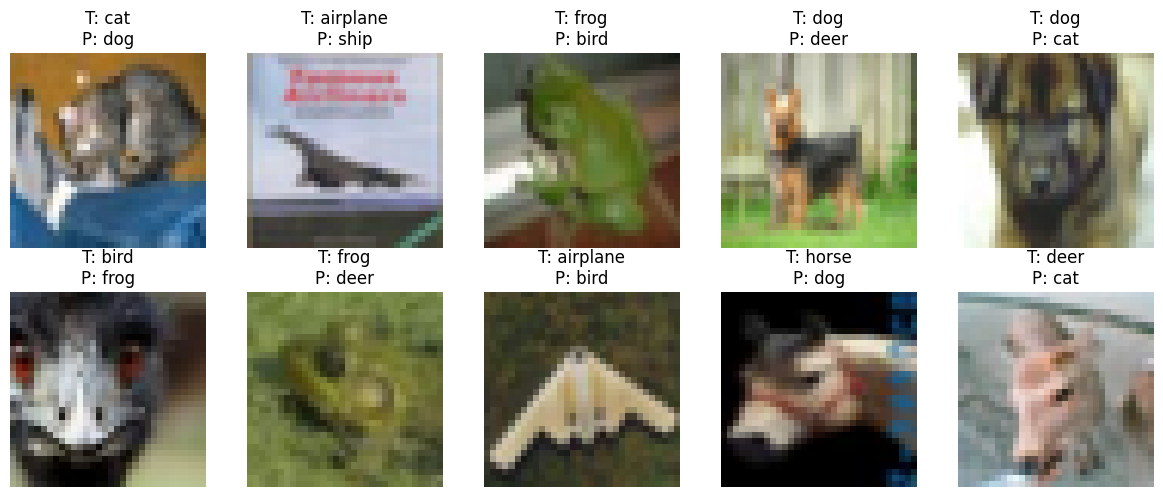

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for idx, (img, true_label, pred_label) in enumerate(misclassified[:10]):
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0)
    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(
        f"T: {classes[true_label]}\nP: {classes[pred_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [20]:
checkpoint = {
'epoch': num_epochs,
'model_state_dict': model.state_dict(),
'optimizer_state_dict': optimizer.state_dict(),
'best_val_acc': best_acc,
}
import os
ckpt_path = os.path.join(".", 'best_model.pth')
torch.save(checkpoint, ckpt_path)

In [21]:
class ResNetBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = out + identity
        out = F.relu(out)

        return out


In [22]:
class SmallCNN_ResNet(nn.Module):
    def __init__(self, classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.resblock = ResNetBlock(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = self.resblock(x)

        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
model = SmallCNN_ResNet()
#checkpoint = torch.load("best_model.pth", map_location=device)

#model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)

SmallCNN_ResNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (resblock): ResNetBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, 

In [25]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


In [26]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
#optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


In [27]:
num_epochs = 30
best_acc = 0.0

early_stopper = EarlyStopping(patience=5)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
for epo in range(num_epochs):
    model.train()
    run_loss = 0.0
    val_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = run_loss / len(train_loader)
    if early_stopper(loss):
        break
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()

    val_loss /= len(test_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if early_stopper(val_loss):
        print("early stopping break")
        break
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_cnn_resnet_cifar10.pth")
        print("Best model saved")



    print(f"epoch = {epo+1} ==> loss = {train_loss} ==> accuracy = {train_acc} ==> val accuracy = {val_acc}")

Best model saved
epoch = 1 ==> loss = 1.491927642727752 ==> accuracy = 45.168 ==> val accuracy = 57.76
Best model saved
epoch = 2 ==> loss = 1.1557544892858667 ==> accuracy = 58.672 ==> val accuracy = 65.6
Best model saved
epoch = 3 ==> loss = 1.0136157819986953 ==> accuracy = 64.356 ==> val accuracy = 68.47
Best model saved
epoch = 4 ==> loss = 0.9228247523002917 ==> accuracy = 67.856 ==> val accuracy = 71.13
Best model saved
epoch = 5 ==> loss = 0.8450626554467794 ==> accuracy = 71.222 ==> val accuracy = 74.34
Best model saved
epoch = 6 ==> loss = 0.7975870915462294 ==> accuracy = 72.744 ==> val accuracy = 76.41
Best model saved
epoch = 7 ==> loss = 0.7495009068332975 ==> accuracy = 74.622 ==> val accuracy = 76.85
Best model saved
epoch = 8 ==> loss = 0.7075979242773007 ==> accuracy = 75.98 ==> val accuracy = 77.16
Best model saved
epoch = 9 ==> loss = 0.6817207041070285 ==> accuracy = 77.086 ==> val accuracy = 77.36
Best model saved
epoch = 10 ==> loss = 0.6509933927861016 ==> accur

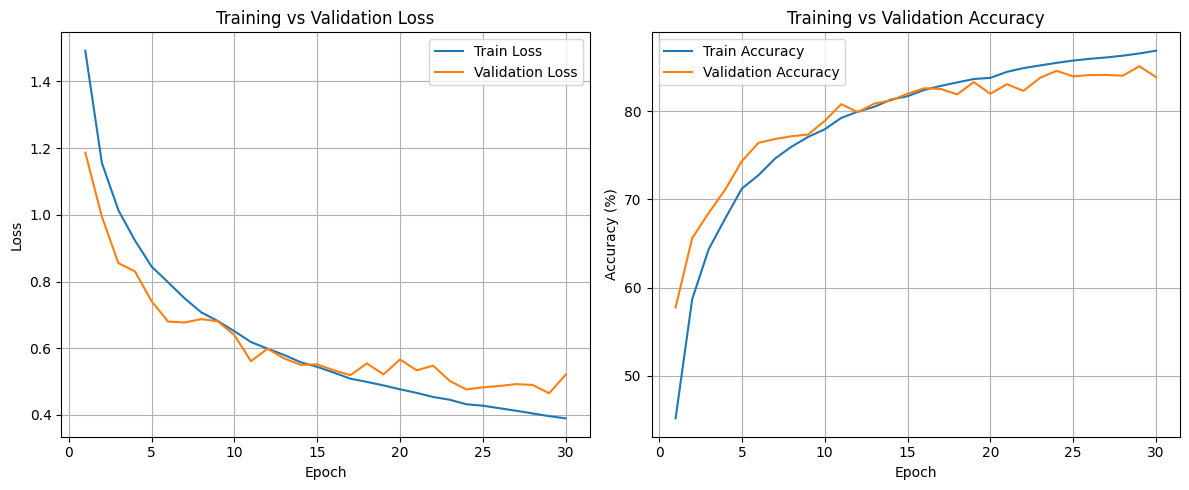

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [29]:
checkpoint = {
'epoch': num_epochs,
'model_state_dict': model.state_dict(),
'optimizer_state_dict': optimizer.state_dict(),
'best_val_acc': best_acc,
}
import os
ckpt_path = os.path.join(".", 'best_cnn_resnet_cifar10_final.pth')
torch.save(checkpoint, ckpt_path)

# Result
####  CNN model - validation accuracy - 82% for 30 epochs
#### resnet CNN model - validation accuracy - 85% for 30 epochs
